# Defensa de Evaluación Grupal — Proyecto de Minería de Datos
## Vulnerabilidad habitacional y acceso a servicios básicos
### Censo de Población y Vivienda 2024 — INE Bolivia

Este guion resume **resultados ya ejecutados** en `entendimiento de datos.ipynb` y `modelado_clasificacion.ipynb`. Sigue las fases de CRISP-DM evaluadas: **1) entendimiento del negocio, 2) entendimiento de los datos, 3) preparación de los datos y 4) modelado**. No vuelve a leer el CSV ni a entrenar modelos. Las cifras del IPS son construcciones de este proyecto, no estadísticas oficiales publicadas por el INE. Las cifras redondeadas se presentan como aparecen en las salidas de ambos notebooks.

## 1. ¿Qué problema concreto aborda el proyecto, qué decisión o acción busca apoyar y cuál es el criterio de éxito de negocio?

El problema es localizar **viviendas con carencias simultáneas** en agua, saneamiento, electricidad e internet. Importa territorialmente porque las necesidades no se distribuyen por igual entre áreas y códigos geográficos; afecta a quienes viven en las viviendas clasificadas y puede orientar dónde revisar y priorizar servicios o inversión pública. El proyecto apoya una **priorización exploratoria de viviendas o zonas**, no asigna beneficios ni demuestra que vivir en cierto territorio cause precariedad.

El criterio operativo de éxito de negocio es producir un **IPS interpretable por vivienda y territorio**, siempre con su denominador y cobertura, para distinguir dónde se concentra la precariedad. En esta etapa no hay una meta numérica de reducción de carencias ni evidencia de una intervención realizada. El IPS observado sirve como línea descriptiva del proyecto; el desempeño predictivo se evalúa aparte.

### Respuesta corta para defensa oral

“Buscamos identificar viviendas con varias carencias de servicios básicos y ver en qué territorios se concentran. Revisamos agua, saneamiento, electricidad e internet. Con el IPS queremos apoyar una priorización informada de zonas para estudiar intervenciones, mostrando siempre cuántas viviendas pudieron clasificarse. La brecha territorial describe una asociación; aún no demuestra una causa ni un impacto de políticas.”

### Evidencia que debemos mostrar

En `entendimiento de datos.ipynb`, mostrar **§1 Contexto del proyecto**, **§9 Índice de Precariedad de Servicios** (tabla IPS por área y cobertura) y **§10 Hallazgos principales**. En `modelado_clasificacion.ipynb`, mostrar **§9 Comparación de modelos y errores relevantes** para el papel de la predicción como apoyo.

### Posible repregunta del docente

1. **¿El 19,60 % es la meta de reducción?** No. Es el IPS **observado** entre viviendas válidas; no se fijó ni midió una meta posterior a una intervención.
2. **¿El área rural provoca las carencias?** La diferencia observada no identifica una causa. Factores sociales, económicos y geográficos pueden intervenir; aquí describimos y predecimos asociaciones.

## 2. ¿Cuál es la métrica principal del proyecto y cómo se calcula?

La métrica principal de análisis es el **Índice de Precariedad de Servicios (IPS)**. Para cada vivienda clasificable definimos cuatro indicadores binarios: carencia de agua, saneamiento, electricidad e internet; `1` significa carencia bajo la regla operacional del proyecto y `0`, ausencia de esa carencia. `n_carencias` es su suma, de 0 a 4. La variable `vivienda_precaria` vale **1 si `n_carencias ≥ 2`** y **0 si `n_carencias < 2`**.

**IPS = (viviendas válidas con dos o más carencias / viviendas válidas en las cuatro dimensiones) × 100.** El notebook reporta **2.635.157 viviendas válidas**, de las cuales **516.494** tienen clase 1: **IPS nacional = 19,60 %**. Esto significa aproximadamente una de cada cinco viviendas *clasificables*, bajo esta definición del proyecto; no significa una de cada cinco de todas las viviendas del CSV.

El denominador no es **3.623.711** porque **988.554 viviendas analíticas** tienen al menos una dimensión que no puede clasificarse con seguridad; quedan sin IPS. La cobertura es **72,72 %** de la población analítica. El IPS es una métrica de negocio/análisis creada aquí, **no un indicador oficial del INE ni una métrica de calidad del modelo** como accuracy o F1.

### Respuesta corta para defensa oral

“El IPS mide el porcentaje de viviendas clasificables que acumulan dos o más de cuatro carencias. Sumamos agua, saneamiento, electricidad e internet y dividimos los casos con al menos dos carencias entre las viviendas con las cuatro dimensiones definidas. Son 2.635.157 viviendas válidas y el IPS observado es 19,60 %. Las otras 988.554 no reciben IPS; por eso informamos también 72,72 % de cobertura. Es una definición del proyecto, no una cifra oficial del INE.”

### Evidencia que debemos mostrar

En `entendimiento de datos.ipynb`, mostrar **§8 Construcción de indicadores de carencia** (reglas) y **§9 Índice de Precariedad de Servicios**, celda que imprime `Viviendas válidas para IPS`, `Excluidas por dimensión no clasificable`, `Cobertura` e `IPS nacional del proyecto`, más la tabla de `n_carencias`. `modelado_clasificacion.ipynb` **§1** reproduce la población y el 19,60 %.

### Posible repregunta del docente

1. **¿Por qué 988.554 no es la suma de los “No clasificable” de cada servicio?** Una misma vivienda puede tener más de una dimensión indefinida; 988.554 es el número de viviendas con **al menos una** dimensión no clasificable.
2. **¿19,60 % es el accuracy de la clasificación?** No. Es prevalencia de la clase precaria bajo el índice. Accuracy mide aciertos del modelo en prueba y se presenta en la pregunta 9.

## 3. ¿Cuál es la unidad de análisis, de dónde provienen los datos y cuántos registros y variables tiene el conjunto?

La fuente es el archivo **VIVIENDA** de microdatos del **Censo de Población y Vivienda 2024 del Instituto Nacional de Estadística de Bolivia (INE)**, con diccionario y cuestionario. La unidad principal es el **registro de vivienda**: cada fila representa una entrada del archivo de vivienda y el identificador `i00` fue único en la base revisada. No debemos equiparar automáticamente vivienda con hogar: algunas preguntas se refieren al hogar y el cuestionario contempla baño compartido entre hogares.

| Etapa | Registros | Qué representa |
|---|---:|---|
| Archivo original | 4.490.488 | 48 variables; incluye registros fuera de la población analítica |
| Población analítica | 3.623.711 | Viviendas particulares de tipos 1–6, ocupadas con personas presentes (`v02_condocup` 0/1), `tot_pers > 0` y preguntas base de servicios aplicables |
| IPS y modelado | 2.635.157 | Subconjunto analítico con las cuatro carencias clasificables |

La selección de viviendas particulares elimina tipos colectivos o sin vivienda; después se restringe a ocupación presente y a servicios aplicables. La última reducción no es un filtro de ocupación: se debe a dimensiones ambiguas o sin especificar que impiden asignar la clase.

### Respuesta corta para defensa oral

“Trabajamos con el archivo de vivienda del Censo 2024 del INE. Tiene 4.490.488 filas y 48 variables. Tras seleccionar viviendas particulares ocupadas con personas presentes quedan 3.623.711; de ellas, 2.635.157 permiten definir las cuatro carencias y entran al IPS y al modelado. Una fila es un registro de vivienda, no necesariamente un hogar distinto.”

### Evidencia que debemos mostrar

En `entendimiento de datos.ipynb`, mostrar **§3 Unidad de análisis**, **§4.1 Dimensiones del dataset** (4.490.488 × 48), **§5.2 Registros duplicados** (`i00` único) y la tabla de flujo al comienzo de **§6 Análisis univariado**. Para el último denominador, **§9 IPS**.

### Posible repregunta del docente

1. **¿Por qué no se usa toda la base original?** Incluye viviendas colectivas, no ocupadas o sin preguntas de servicios aplicables; mezclarlas cambiaría la población que se quiere describir.
2. **¿Una vivienda equivale exactamente a un hogar?** No necesariamente. La entidad del archivo es VIVIENDA y hay preguntas formuladas para el hogar; no se dispone aquí de una columna explícita de número de hogar para suponer una equivalencia uno a uno.

## 4. ¿Qué problemas de calidad encontraron y qué preparación aplicaron?

El diagnóstico de **NaN en el CSV original** distingue vacíos de categorías especiales escritas como código. Una muestra útil es:

| Columna | NaN en 4.490.488 filas | Interpretación documentada |
|---|---:|---|
| `v02_condocup` | 26.715 | Revisar aplicabilidad de condición de ocupación |
| `v07_aguapro` | 866.777 | Mismo patrón de vacío de preguntas de servicios fuera de la población aplicable |
| `v09_energia` | 866.777 | Igual patrón de aplicabilidad |
| `v15_servsan` | 866.777 | Igual patrón de aplicabilidad |
| `v16_desague` | 1.601.034 | Incluye salto válido: 734.257 viviendas analíticas sin baño tienen desagüe vacío |
| `v19e_f` | 866.777 | Variable combinada de internet fuera de preguntas aplicables |
| `v20b_totemi` | 4.187.319 | Pregunta condicionada; un vacío no prueba por sí mismo error |
| `v21b_totfal` | 4.145.006 | Pregunta condicionada; un vacío no prueba por sí mismo error |

En el conjunto analítico, **734.257** viviendas declaran no tener baño/letrina y **todas** dejan vacío `v16_desague`: es un salto lógico, pero se clasifican con carencia de saneamiento. Se observaron **0 filas completamente duplicadas**, **0 identificadores `i00` repetidos** y **0 variables documentadas con códigos fuera de su lista**. La variable combinada de internet coincidió con fijo/móvil en **3.491.434 casos determinables**: 0 desacuerdos.

La preparación aplicó reglas conservadoras: agua, códigos `1,2,4,6` sin carencia; `5,7` con carencia; `3,8,9` sin clasificación. Saneamiento, baño exclusivo (`v15=1`) con desagüe `1,2,6` sin carencia; baño compartido o inexistente (`v15=2,3`) o desagüe a superficie (`v16=5` con `v15=1`) con carencia; baño exclusivo con desagüe `3,4` sin clasificación. Electricidad, `v09_energia=1–4` sin carencia y `5` con carencia. Internet combinado `v19e_f=1` sin carencia, `2` con carencia y `9` (“Sin especificar”) sin clasificación. **No se imputaron** valores ambiguos.

| Dimensión | No clasificable dentro de 3.623.711 analíticas | N válido | Carencia entre válidas |
|---|---:|---:|---:|
| Agua | 239.177 | 3.384.534 | 8,39 % |
| Saneamiento | 691.976 | 2.931.735 | 42,56 % |
| Electricidad | 0 | 3.623.711 | 10,52 % |
| Internet | 131.692 | 3.492.019 | 23,73 % |

Las **988.554** viviendas sin IPS son la unión de los casos con alguna dimensión no clasificable. Estas cantidades no se suman porque una vivienda puede aparecer en varias dimensiones.

### Respuesta corta para defensa oral

“Encontramos vacíos, códigos ‘Sin especificar’ y categorías cuya protección o calidad no podía deducirse. Un caso clave: si la vivienda no tiene baño, desagüe queda vacío por el salto del cuestionario, y eso no es un error. Verificamos cero duplicados exactos y cero códigos fuera del diccionario. Clasificamos solo cuando la regla era defendible y no imputamos las categorías ambiguas; por eso 988.554 viviendas analíticas quedaron sin IPS.”

### Evidencia que debemos mostrar

En `entendimiento de datos.ipynb`, mostrar **§5.1 Valores faltantes** (tabla NaN), **§5.2 Registros duplicados**, **§5.3–5.4 Códigos e inconsistencias**, **§6.3 Saneamiento** (734.257 vacíos por salto), **§6.5 Internet** (concordancia) y **§8 Construcción de indicadores** (tabla `No clasificable`). La celda inicial de **§9** muestra las 988.554 excluidas del IPS.

### Posible repregunta del docente

1. **¿Un desagüe vacío siempre se debe eliminar?** No. Para viviendas sin baño es un salto válido y la carencia se clasifica por `v15_servsan=3`; otros vacíos requieren revisar contexto.
2. **¿Por qué no llamar “sin carencia” al agua de lluvia o al carro repartidor?** La categoría no certifica protección ni potabilidad; asignar 0 o 1 sería una suposición que podría sesgar el IPS.

## 5. ¿Qué resultado interesante encontraron en la exploración y qué gráfico lo demuestra?

El hallazgo central es la **brecha urbano-rural del IPS** entre viviendas con las cuatro dimensiones clasificables:

| Área | N válido | Viviendas precarias | IPS | Cobertura del IPS |
|---|---:|---:|---:|---:|
| Urbana | 1.916.157 | 101.706 | 5,31 % | 80,28 % |
| Rural | 719.000 | 414.788 | 57,69 % | 58,13 % |

La diferencia rural menos urbana es **52,38 puntos porcentuales**. La **tabla “IPS por área” de §9** demuestra directamente esta diferencia. El **gráfico “Carencia de servicios por área” de §7.1** muestra las cuatro carencias separadas por área y ayuda a explicar el contexto, pero **no representa el IPS agregado**; para defender el 5,31 % frente al 57,69 % debemos enseñar la tabla. La comparación es descriptiva, no causal. La menor cobertura rural obliga a interpretar la brecha con cautela.

Como dato secundario, saneamiento tiene **42,56 %** de carencia entre sus **2.931.735** casos clasificables y agua **8,39 %** entre **3.384.534**; sus denominadores son distintos.

### Respuesta corta para defensa oral

“La brecha más clara es territorial: entre viviendas con IPS calculable, el valor urbano es 5,31 % y el rural 57,69 %, una diferencia de 52,38 puntos. Lo demostraría con la tabla IPS por área. El gráfico de carencias por área complementa la explicación, aunque no grafica el IPS. La cobertura es desigual —80,28 % urbana y 58,13 % rural—, así que no interpretamos la diferencia como efecto causal.”

### Evidencia que debemos mostrar

En `entendimiento de datos.ipynb`, mostrar **§9 Índice de Precariedad de Servicios**, tabla `IPS por área` con `N_validas`, `N_precarias`, `IPS_%` y `Cobertura_%`; después **§7.1 Servicios básicos según área urbana/rural**, gráfico **“Carencia de servicios por área”** para contextualizar dimensiones. **§10 Hallazgos principales** confirma la brecha de 52,38 puntos. No hay un gráfico del IPS urbano-rural agregado en el notebook original.

### Posible repregunta del docente

1. **¿El 57,69 % corresponde a todas las viviendas rurales?** No. Corresponde a las **719.000 rurales válidas para IPS**; la cobertura rural es 58,13 % de la población rural analítica.
2. **¿La brecha demuestra que lo rural causa precariedad?** No. Es una asociación descriptiva con cobertura desigual; para hablar de causalidad haría falta otro diseño de estudio.

## 6. ¿Cuál es la variable objetivo, qué clases tiene y qué modelos utilizaron?

La variable objetivo es `vivienda_precaria`, definida solo si las cuatro carencias pueden clasificarse. **Clase 0**: cero o una carencia; **clase 1**: dos, tres o cuatro carencias. Se compararon **regresión logística** y **árbol de decisión para clasificación** sobre el mismo conjunto de prueba. La clasificación es binaria, por lo que ambos modelos son apropiados para la tarea y fueron estudiados en clase. La regresión logística entrega probabilidades y coeficientes asociados a categorías; el árbol muestra reglas, rutas e importancia por reducción de impureza. Ambos usan otras características habitacionales, no las variables que construyen la clase.

### Respuesta corta para defensa oral

“Queremos predecir `vivienda_precaria`: cero significa menos de dos carencias y uno significa dos o más. Solo asignamos esa clase si agua, saneamiento, electricidad e internet pudieron clasificarse. Probamos regresión logística y árbol de decisión, porque el resultado es binario. La primera da probabilidades y coeficientes; el segundo permite seguir reglas. Los comparamos en la misma prueba.”

### Evidencia que debemos mostrar

En `entendimiento de datos.ipynb`, mostrar **§9 IPS**, código de `n_carencias` y `vivienda_precaria`. En `modelado_clasificacion.ipynb`, mostrar **§1 Datos, documentación y población analítica** (reproducción de la clase), **§5 Regresión logística** y **§7 Árbol de decisión**.

### Posible repregunta del docente

1. **¿Por qué no usar regresión lineal?** La clase es binaria; estos clasificadores entregan una decisión 0/1 y permiten evaluarla con precisión, recall, matriz de confusión y ROC-AUC.
2. **¿El modelo predice directamente el IPS nacional?** No. Predice una clase por vivienda; el IPS resume la proporción observada de clase 1 entre viviendas válidas.

## 7. ¿Qué proporción utilizaron para entrenamiento y prueba y cómo evitaron fuga de información?

De **2.635.157** viviendas con clase, **2.108.125** fueron a entrenamiento (**80 %**) y **527.032** a prueba (**20 %**). La instrucción real fue `train_test_split(..., test_size=0.20, random_state=42, stratify=y)`. `stratify=y` mantiene aproximadamente **80,4 % clase 0 y 19,6 % clase 1** en ambos conjuntos. Los índices de entrenamiento y prueba se verificaron sin solapamiento.

La prevención de *data leakage* comienza por excluir de `X` las cuatro `carencia_*`, `n_carencias`, `vivienda_precaria` y cualquier representación del IPS. También se excluyeron las fuentes originales que definen la clase: `v07_aguapro`, `v15_servsan`, `v16_desague`, `v09_energia`, `v19e_f` y las componentes de internet fijo/móvil `v19e_inetfijo`, `v19f_inetmovil`. Por prudencia se excluyeron `v08_aguadist`, combustible para cocinar `v10_combus`, equipamiento/TIC y claves `i00`, `idep`, `iprov`, `imun`. **`urbrur` sí se usó** porque es un contexto territorial interpretable y no define directamente el objetivo. Si usáramos las respuestas de agua, baño, electricidad e internet para predecir la clase construida a partir de ellas, el modelo conocería indirectamente la respuesta.

La codificación `OneHotEncoder(handle_unknown="ignore", drop="first")` vive dentro de `ColumnTransformer` y `Pipeline`; el pipeline se ajustó después de dividir los datos, usando `X_train` para el modelo final. La profundidad del árbol se escogió con validación dentro del entrenamiento, no mirando la prueba.

### Respuesta corta para defensa oral

“Dividimos 80/20: 2.108.125 viviendas para entrenar y 527.032 para prueba, con semilla 42 y estratificación para mantener la proporción de clases. Evitamos fuga excluyendo tanto las carencias y su suma como las preguntas de servicios que las generan. Además, el One-Hot Encoder está dentro del pipeline y aprende sus categorías solo del entrenamiento. La prueba queda reservada para la evaluación final.”

### Evidencia que debemos mostrar

En `modelado_clasificacion.ipynb`, mostrar **§2 Prevención de fuga de información** (tabla `Variable | Motivo de exclusión` y aserción de intersección vacía), **§3 Selección de predictores** (diez variables usadas), **§4 Partición entrenamiento/prueba** (código `random_state=42`, `stratify=y`, recuentos y distribución), y **§7** (validación del árbol dentro del entrenamiento).

### Posible repregunta del docente

1. **¿Se excluyó toda variable territorial?** Se excluyeron las claves geográficas `idep`, `iprov`, `imun`, pero se conservó `urbrur` como contexto urbano/rural. Esta decisión no elimina la necesidad de validar generalización territorial.
2. **¿Basta con separar train/test si codificamos antes?** No. Un encoder ajustado antes del split podría aprender información de la prueba. Aquí el encoder se ajusta dentro del pipeline con entrenamiento.

## 8. ¿Cuáles son las variables más importantes según el modelo y cómo determinaron su importancia?

En el **árbol**, `feature_importances_` mide cuánto contribuyó cada categoría codificada a reducir impureza en los nodos usados. La categoría dominante fue `categoricas__urbrur_2` (**área rural**, frente a urbana) con importancia **0,80900**. Le siguieron `v01_tipoviv_4` (cuarto o habitación suelta) **0,03795**, `v11_basura_5` (queman basura) **0,03722**, `v06_piso_4` (cerámica/porcelanato) **0,03698** y `v11_basura_2` (entrega al carro basurero) **0,03119**. Las importancias suman la contribución de las categorías codificadas y no son efectos causales.

En la **regresión logística**, el gráfico y la tabla recuperan los nombres después de One-Hot Encoding. Entre los coeficientes positivos mayores están `v11_basura_4` (**la botan al río**, **+1,5128**), `v11_basura_6` (**la entierran**, **+1,3880**) y `v01_tipoviv_4` (**cuarto o habitación suelta**, **+1,3879**). `urbrur_2` tiene coeficiente **+0,9969** frente a área urbana. El coeficiente más negativo es `v01_tipoviv_3` (**departamento**, **−6,7103**) frente a la categoría de referencia `v01_tipoviv_1` (**casa**); sigue `v06_piso_4` (**cerámica/porcelanato**, **−1,7969**) frente a piso de tierra. Cada signo expresa asociación con las *log-odds* estimadas de clase 1, manteniendo las demás variables del modelo constantes y respecto a la categoría omitida. **No demuestra causalidad** ni debe leerse como efecto de cambiar una vivienda.

Una explicación defendible: el modelo encuentra asociación entre **área rural** y mayor probabilidad estimada de clase precaria, con las demás variables incluidas constantes; eso no prueba que el área rural sea su causa.

### Respuesta corta para defensa oral

“El árbol da mucha importancia al indicador de área rural: 0,809 de importancia por reducción de impureza. También aparecen tipo de vivienda, eliminación de basura y material de piso. En logística, las categorías con coeficientes positivos destacados incluyen botar basura al río, enterrarla y vivir en un cuarto suelto; departamento tiene el coeficiente negativo más marcado frente a casa. Son asociaciones del modelo, no causas.”

### Evidencia que debemos mostrar

En `modelado_clasificacion.ipynb`, mostrar **§6 Coeficientes de la regresión logística**, sus tablas de positivos/negativos, referencias y gráfico; luego **§8 Importancia y visualización del árbol**, tabla de 15 categorías y gráfico. El diccionario oficial de `entendimiento de datos.ipynb` **§4.4** confirma las etiquetas de códigos.

### Posible repregunta del docente

1. **¿Una importancia de 0,809 equivale a 80,9 % de viviendas rurales precarias?** No. Es la proporción de reducción de impureza atribuida a esa categoría en el árbol, no una tasa de viviendas ni un efecto causal.
2. **¿Qué significa `urbrur_2` con coeficiente positivo?** La categoría rural está asociada a mayores log-odds estimadas de clase 1 frente a la referencia urbana, con las otras variables del modelo constantes; no implica causalidad.

## 9. ¿Qué desempeño obtuvo el modelo en prueba?

La clase positiva es **1 = vivienda precaria**. Las cinco métricas se calcularon sobre las **mismas 527.032 viviendas de prueba**:

| Modelo | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Regresión logística | 0,8633 (86,33 %) | 0,6077 (60,77 %) | 0,8534 (85,34 %) | 0,7099 (70,99 %) | 0,9303 (93,03 %) |
| Árbol de decisión | 0,8601 (86,01 %) | 0,6057 (60,57 %) | 0,8199 (81,99 %) | 0,6967 (69,67 %) | 0,9052 (90,52 %) |

| Modelo | TN: real 0, predicha 0 | FP: real 0, predicha 1 | FN: real 1, predicha 0 | TP: real 1, predicha 1 |
|---|---:|---:|---:|---:|
| Regresión logística | 366.819 | 56.914 | 15.148 | 88.151 |
| Árbol de decisión | 368.593 | 55.140 | 18.606 | 84.693 |

**Accuracy** es el porcentaje total de aciertos `(TP+TN)/N`. **Precision** es `TP/(TP+FP)`: de las viviendas señaladas como precarias, cuántas realmente lo son. **Recall** es `TP/(TP+FN)`: de las realmente precarias, cuántas detectamos. **F1** combina precision y recall (media armónica). **ROC-AUC** resume la capacidad de ordenar clases a distintos umbrales; no equivale a accuracy. Un **FP** es una vivienda no precaria marcada como precaria; un **FN**, una precaria clasificada como no precaria.

Para priorización, un FN podría dejar fuera de revisión una vivienda realmente precaria. Recomendamos **regresión logística** porque supera al árbol en las cinco métricas reportadas y registra **3.458 FN menos**, aunque tiene **1.774 FP más**. Hay que sopesar recursos y costos; ninguno es perfecto ni reemplaza verificación de campo.

### Respuesta corta para defensa oral

“En la misma prueba de 527.032 viviendas, la logística obtuvo 86,33 % de accuracy, 85,34 % de recall y F1 de 70,99 %; el árbol obtuvo 86,01 %, 81,99 % y 69,67 %. La logística registró 15.148 falsos negativos y el árbol 18.606. Recomendamos logística para priorización exploratoria porque recupera más viviendas precarias y supera al árbol en las métricas reportadas, aunque genera más falsos positivos y requiere revisión posterior.”

### Evidencia que debemos mostrar

En `modelado_clasificacion.ipynb`, mostrar **§5 Regresión logística** (tabla, `classification_report` y matriz de confusión), **§7 Árbol de decisión** (equivalentes) y **§9 Comparación de modelos y errores relevantes**. Las matrices tienen **filas reales** `[0,1]` y **columnas predichas** `[0,1]`; de ahí salen TN, FP, FN y TP.

### Posible repregunta del docente

1. **¿Por qué accuracy no basta?** La clase precaria representa 19,6 %; un modelo puede acertar muchos casos de clase 0 y aun así omitir demasiados positivos. Por eso revisamos recall, precision, F1 y matriz.
2. **¿Hay que reducir siempre los FN sin límite?** No. Cambiar umbral o pesos puede bajar FN a costa de más FP; la prioridad depende de capacidad de revisión y costo de ambos errores.

## 10. ¿Qué visualización permite entender cómo toma decisiones el modelo?

El **árbol** permite seguir condiciones concretas. La figura original de **§8** muestra los primeros tres niveles (raíz y dos niveles más), con variable, umbral, `gini`, `samples`, `value` y clase predominante. La ruta real impresa de la primera vivienda de prueba (índice original **2.087.807**) empieza por `categoricas__urbrur_2 (0) <= 0.50`: el indicador rural vale 0, es decir, **urbana**. Sigue `categoricas__v11_basura_5 (0) <= 0.50`: no pertenece a la categoría **queman la basura**. Luego `categoricas__v01_tipoviv_4 (0) <= 0.50`: no es **cuarto o habitación suelta**. Esos tres pasos se ven en la figura. La ruta impresa continúa con `categoricas__v14_dormit_1 (0) <= 0.50` y `categoricas__v01_tipoviv_6 (0) <= 0.50`, que quedan **fuera de la vista parcial**; termina en la **hoja 5**, con **881.452** muestras de entrenamiento, predicción **clase 0** y probabilidad estimada de clase 1 **0,0691**. No se inventa una rama: todas las condiciones proceden de `decision_path` del árbol entrenado.

El **gráfico de coeficientes de la regresión logística** muestra categorías con asociación positiva o negativa con las log-odds de clase 1 frente a su referencia, con las demás variables del modelo constantes. El signo ayuda a resumir tendencias; la magnitud no prueba causalidad. Para explicar **una decisión concreta** en la defensa usaríamos el árbol y su ruta; para explicar asociaciones generales del modelo usaríamos el gráfico logístico. La figura del árbol es parcial, por lo que la ruta completa se debe apoyar con la salida de texto.

### Respuesta corta para defensa oral

“Para explicar una predicción enseñaría el árbol. En una ruta real, la vivienda de prueba es urbana, no está en la categoría ‘queman la basura’ y no es un cuarto suelto; el árbol sigue dos condiciones más y llega a una hoja que predice clase 0. La figura solo muestra los primeros niveles, así que leo el resto de la ruta impresa. El gráfico logístico complementa con categorías asociadas positiva o negativamente a la clase 1, sin afirmar causas.”

### Evidencia que debemos mostrar

En `modelado_clasificacion.ipynb`, mostrar **§8 Importancia y visualización del árbol**, figura **“Árbol de decisión — Primeros niveles”** y salida **“Condiciones de la ruta real”** debajo; luego **§6 Coeficientes**, gráfico **“Coeficientes destacados — Regresión logística”** y tabla de referencias. Las imágenes siguientes son copias de esas salidas ejecutadas.

### Posible repregunta del docente

1. **¿La figura muestra la hoja 5?** No. Es una vista parcial de tres niveles; la hoja y las dos condiciones restantes aparecen en la salida textual calculada del árbol.
2. **¿Por qué un coeficiente positivo no significa que una variable cause precariedad?** El modelo observacional aprende asociaciones entre variables y clase. No controla experimentalmente otros factores ni prueba qué ocurriría si se cambiara esa característica.

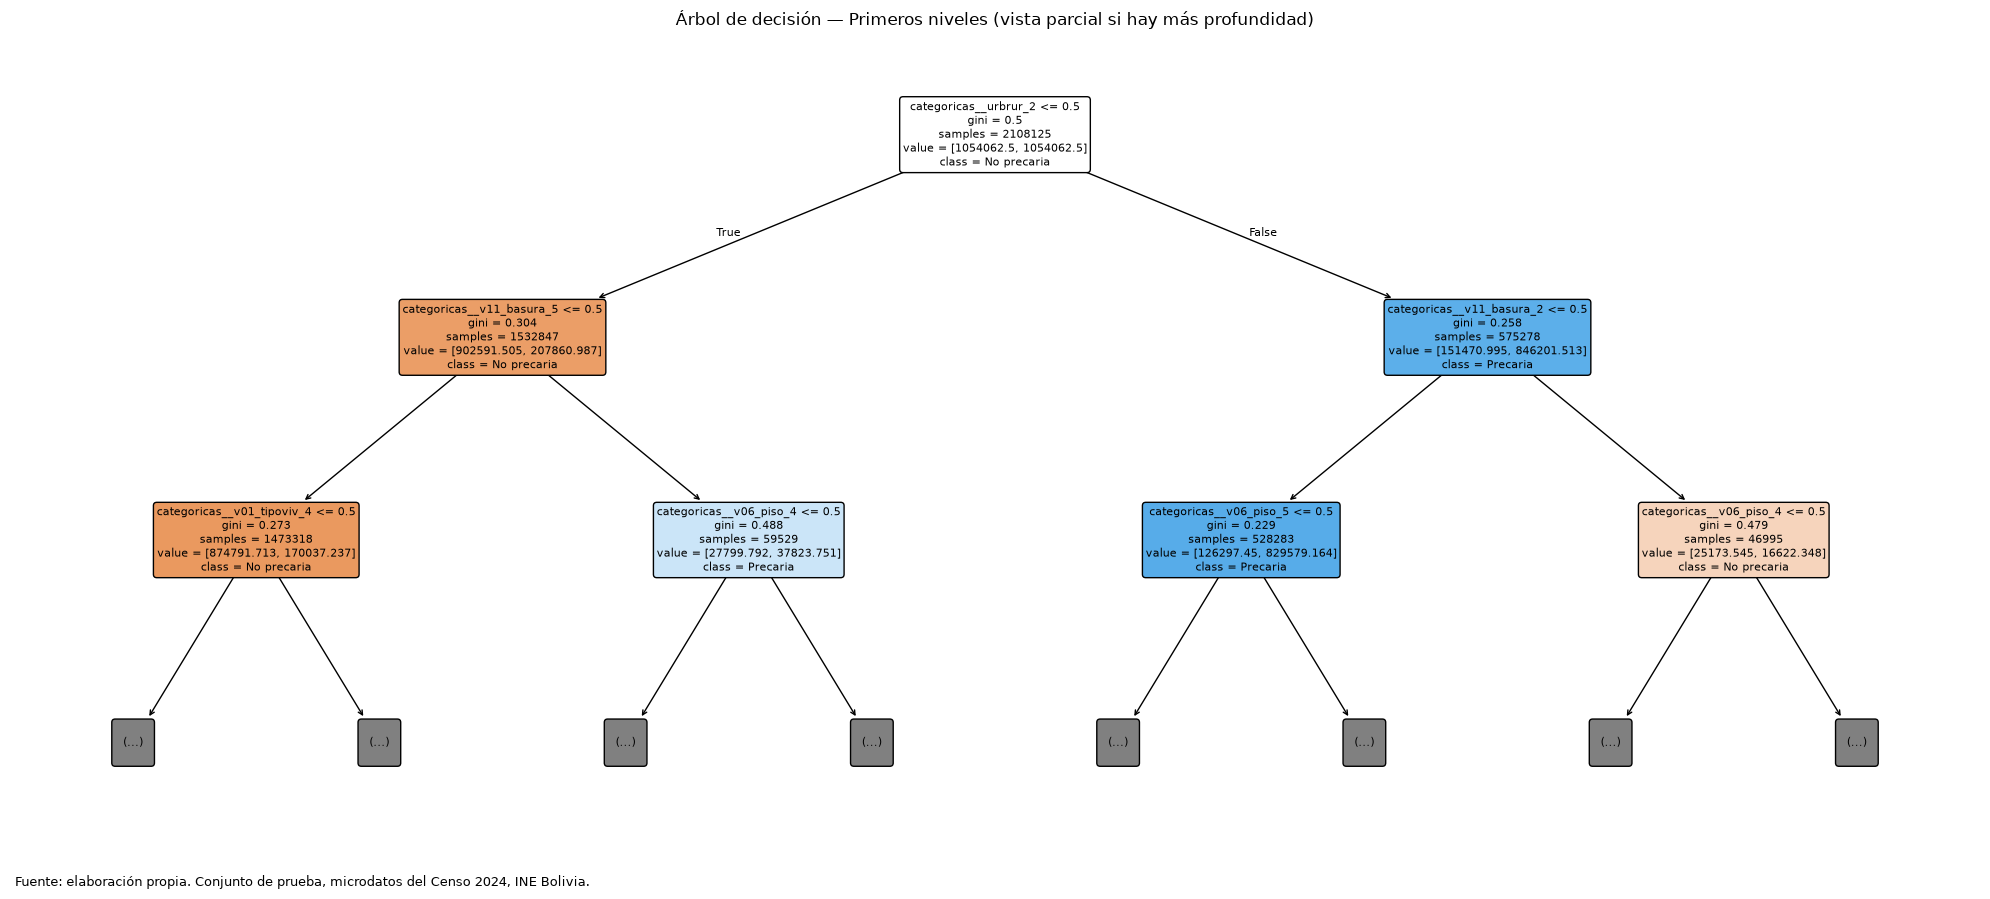

*Árbol real entrenado: primeros niveles, vista parcial. Imagen tomada de la salida ejecutada de `modelado_clasificacion.ipynb`; no se recalculó ni se entrenó de nuevo.*

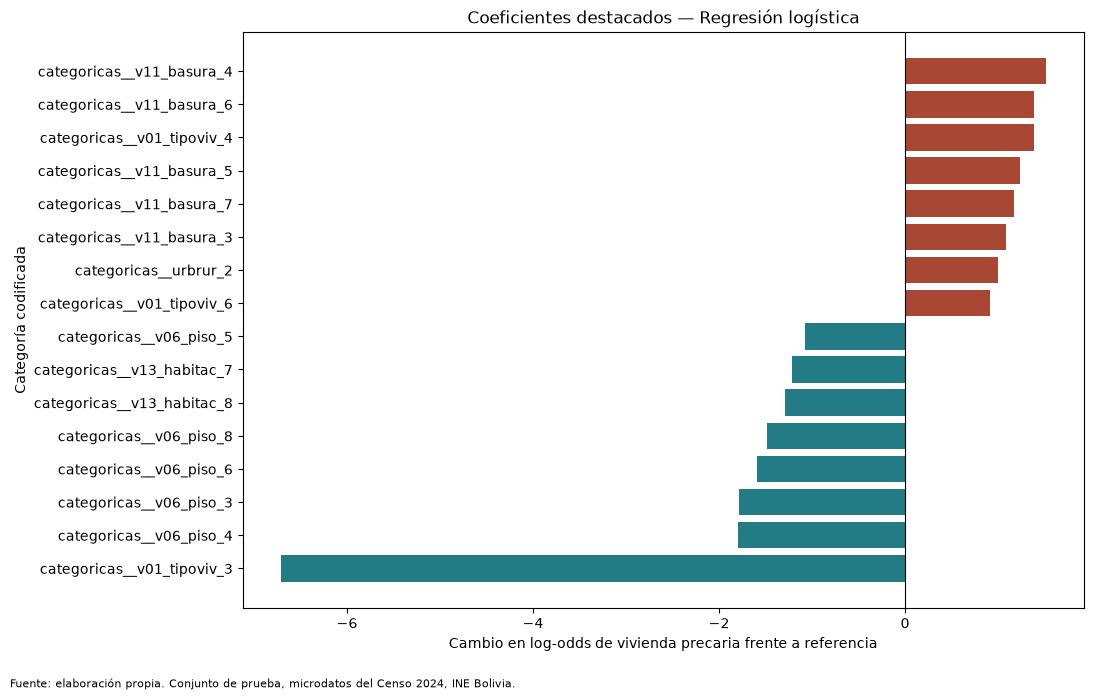

*Gráfico real de coeficientes destacados de la regresión logística. Imagen tomada de la salida ejecutada de `modelado_clasificacion.ipynb`; no se recalculó ni se entrenó de nuevo.*

# Resumen numérico para memorizar

| Resultado | Valor verificado |
|---|---:|
| Base original | 4.490.488 registros |
| Variables originales | 48 |
| Población analítica | 3.623.711 viviendas |
| Válidas para IPS/modelado | 2.635.157 viviendas |
| Excluidas del IPS por al menos una dimensión no clasificable | 988.554 viviendas |
| Cobertura IPS | 72,72 % |
| IPS nacional del proyecto | 19,60 % |
| IPS urbano | 5,31 % |
| IPS rural | 57,69 % |
| Brecha rural − urbana | 52,38 puntos porcentuales |
| Entrenamiento | 2.108.125 viviendas |
| Prueba | 527.032 viviendas |
| Accuracy logística | 86,33 % |
| Recall logística | 85,34 % |
| F1 logística | 70,99 % |
| ROC-AUC logística | 93,03 % |
| Accuracy árbol | 86,01 % |
| Recall árbol | 81,99 % |
| F1 árbol | 69,67 % |
| ROC-AUC árbol | 90,52 % |

**No confundir:** IPS es una proporción observada de viviendas clasificables; accuracy y las demás métricas evalúan predicciones en prueba. Los porcentajes de métricas corresponden a los valores decimales redondeados que muestran las tablas del notebook de modelado.

# Conceptos que todos los integrantes deben dominar

| Concepto | Explicación sencilla en este proyecto |
|---|---|
| CRISP-DM | Proceso que ordena el trabajo: entender el problema, entender y preparar datos, modelar y evaluar. Esta defensa cubre las cuatro primeras fases trabajadas. |
| Unidad de análisis | Qué representa cada fila: aquí, un registro de vivienda del archivo VIVIENDA; no se presupone un hogar por fila. |
| IPS | Porcentaje de viviendas válidas con dos o más carencias; es una medida del proyecto, no oficial del INE. |
| Variable objetivo | Lo que queremos clasificar: `vivienda_precaria`, 0 o 1. |
| Variable predictora | Dato usado por el modelo para estimar la clase, como área o material de piso, sin incluir las respuestas que crean la clase. |
| Clasificación binaria | Elegir entre dos clases: no precaria (0) y precaria (1). |
| Train/test | Entrenamiento aprende el modelo; prueba reservada evalúa qué tal predice en registros no usados para ajustarlo. |
| Estratificación | División que conserva aproximadamente la proporción de clases 0 y 1 en ambos grupos. |
| Data leakage o fuga | Información que revela directa o indirectamente la respuesta entra en los predictores o en el ajuste; haría engañosas las métricas. |
| One-Hot Encoding | Convierte una categoría en columnas indicadoras 0/1; aquí se omite una categoría de referencia por variable. |
| Regresión logística | Clasificador que estima una probabilidad de clase 1 y usa coeficientes para relacionar predictores con log-odds. |
| Árbol de decisión | Clasificador que divide datos mediante preguntas sucesivas y termina en hojas con una clase predicha. |
| Matriz de confusión | Tabla de clases reales frente a clases predichas; aquí filas reales y columnas predichas, orden 0 y 1. |
| TP | Verdadero positivo: precaria real y predicha precaria. |
| TN | Verdadero negativo: no precaria real y predicha no precaria. |
| FP | Falso positivo: no precaria real, pero predicha precaria. |
| FN | Falso negativo: precaria real, pero predicha no precaria. |
| Accuracy | `(TP+TN)/total`: proporción total de predicciones correctas. |
| Precision | `TP/(TP+FP)`: qué fracción de las señaladas como precarias lo era realmente. |
| Recall | `TP/(TP+FN)`: qué fracción de las realmente precarias detectamos. |
| F1 | Media armónica de precision y recall; resume ambos en un valor. |
| ROC-AUC | Resume la separación/ordenación entre clases a diferentes umbrales de decisión; 1 indica separación perfecta, 0,5 ordenación azarosa. |
| Coeficiente | En logística, cambio asociado en log-odds frente a categoría de referencia, con otras variables del modelo constantes; no es causal. |
| Feature importance | En el árbol, contribución relativa de una categoría a reducir impureza durante las divisiones; no es causal. |
| Asociación vs causalidad | Asociación: dos características se observan juntas. Causalidad: cambiar una produce un cambio en otra; este análisis observacional no lo demuestra. |